<a href="https://colab.research.google.com/github/Anusunny1211/College-Projects/blob/main/MINI_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install pyod
import os
import numpy as np
from pyod.models import hbos
from pyod.utils.data import evaluate_print
from sklearn.metrics import confusion_matrix,cohen_kappa_score,f1_score
from scipy import signal
import matplotlib.pyplot as plt
import pickle
import pandas as pd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyod: filename=pyod-2.0.2-py3-none-any.whl size=198469 sha256=e98714a01cd9e719ba83d8feecc33d0868b595ba9637dff45d695f8b9d263ade
  Stored in directory: /root/.cache/pip/wheels/77/c2/20/34d1f15b41b701ba69f42a32304825810d680754d509f91391
Successfully built pyod


In [ ]:
channels = 32
seconds = 0.5    # Size of each segment we want
fs = 256.0         # Dtaset eeg sampling rate
data_portion = 1
save_model = False

In [ ]:
df = pd.read_csv('/content/emotions (2).csv')
df.head()

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.62,30.3,-356.0,15.6,26.3,1.070,0.411,-15.70,2.06,3.15,...,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00,NEGATIVE
1,28.80,33.1,32.0,25.8,22.8,6.550,1.680,2.88,3.83,-4.82,...,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57,NEUTRAL
2,8.90,29.4,-416.0,16.7,23.7,79.900,3.360,90.20,89.90,2.03,...,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00,POSITIVE
3,14.90,31.6,-143.0,19.8,24.3,-0.584,-0.284,8.82,2.30,-1.97,...,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40,POSITIVE
4,28.30,31.3,45.2,27.3,24.5,34.800,-5.790,3.06,41.40,5.52,...,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60,NEUTRAL


In [ ]:
sample = df.loc[0, 'fft_0_a':'fft_749_a']
plt.figure(figsize=(16, 10))
plt.plot(range(len(sample)), sample)
plt.title("Features fft_0_b through fft_749_b")
plt.show()

In [ ]:
data = pd.read_csv("/content/emotions (2).csv")
len(data)
pos = data.loc[data["label"]=="POSITIVE"]
sample_pos = pos.loc[2, 'fft_0_b':'fft_749_b']
neg = data.loc[data["label"]=="NEGATIVE"]
sample_neg = neg.loc[0, 'fft_0_b':'fft_749_b']
neu = data.loc[data["label"]=="NEUTRAL"]
sample_neu = neu.loc[1, 'fft_0_b':'fft_749_b']

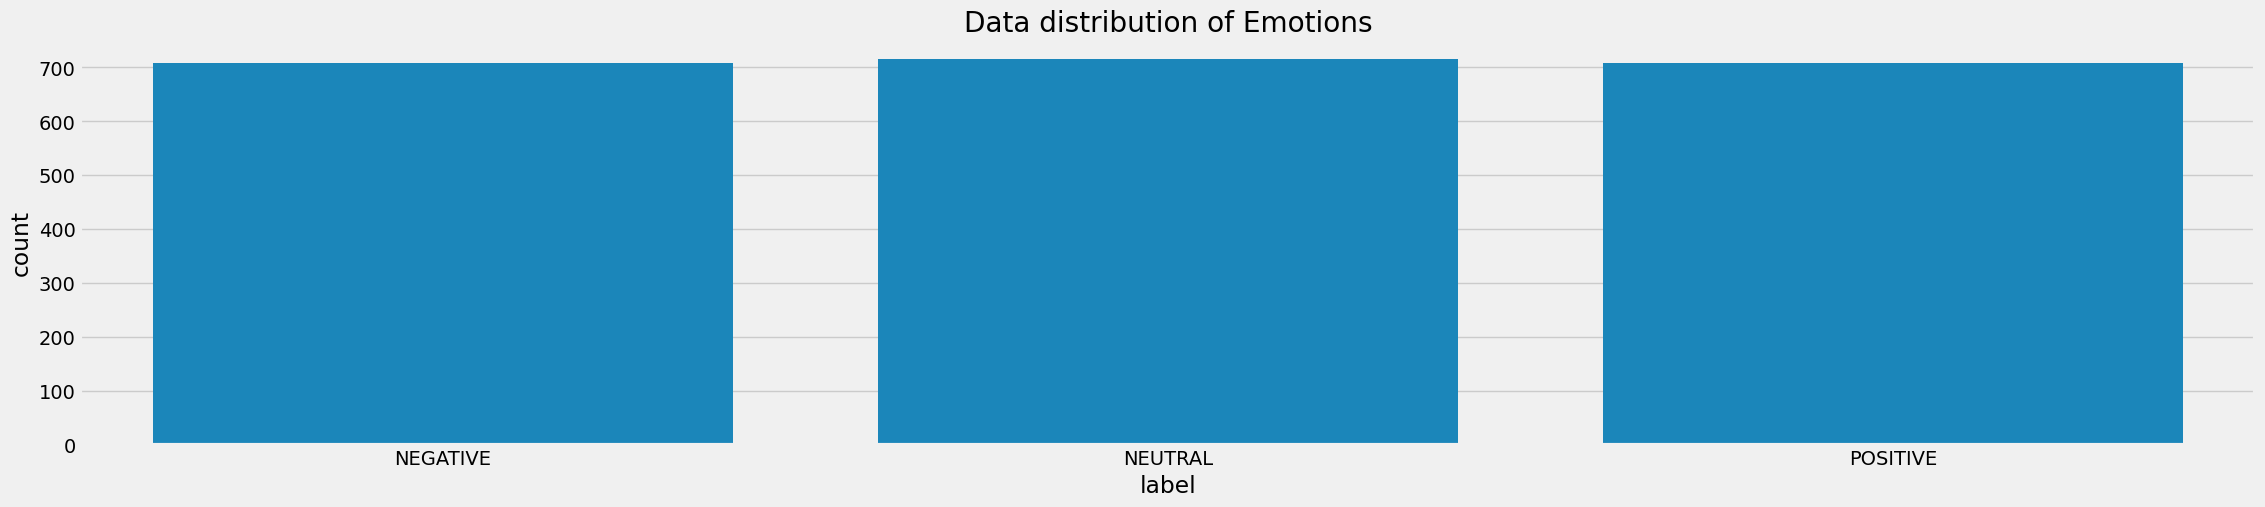

In [ ]:
import seaborn as sns
plt.figure(figsize=(25,5))
plt.title("Data distribution of Emotions")
plt.style.use('fivethirtyeight')
sns.countplot(x='label', data=data)
plt.show()

<ipython-input-27-7e92a9153560>:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_encoded = data.replace(label_mapping)


Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.8035 - loss: 0.5385 - val_accuracy: 0.9357 - val_loss: 0.1755
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9066 - loss: 0.2181 - val_accuracy: 0.9474 - val_loss: 0.1082
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.9409 - loss: 0.1457 - val_accuracy: 0.9474 - val_loss: 0.0909
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9606 - loss: 0.1113 - val_accuracy: 0.9708 - val_loss: 0.0843
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9744 - loss: 0.0834 - val_accuracy: 0.9474 - val_loss: 0.0949
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9637 - loss: 0.0972 - val_accuracy: 0.9357 - val_loss: 0.1527
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9675 - loss: 0.0910 - val_accuracy: 0.9766 - val_loss: 0.0714
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9869 - loss: 0.0424 - val_accuracy: 0.9825 - val_loss:

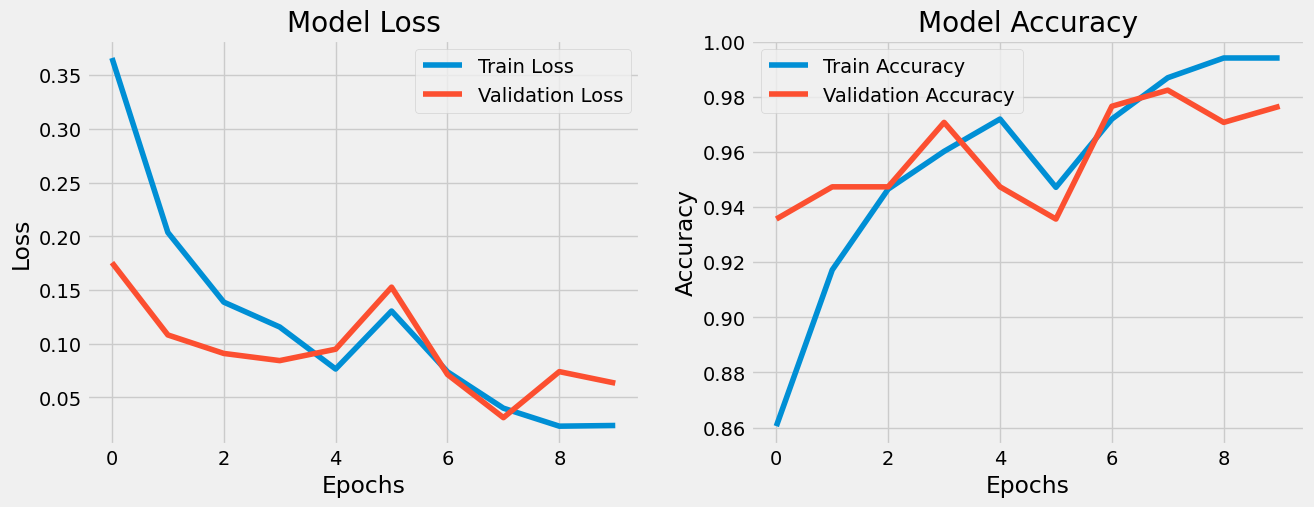

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Input, LayerNormalization, MultiHeadAttention, Dropout
from sklearn.model_selection import train_test_split
from transformers import TFBertModel, BertTokenizer
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
data = pd.read_csv("/content/emotions (2).csv")

# Step 1: Preprocess the EEG Signals
def preprocess_data(data):
    label_mapping = {'NEUTRAL': 0, 'POSITIVE': 1, 'NEGATIVE': 2}
    data_encoded = data.replace(label_mapping)

    X = data_encoded.drop(columns=['label'])  # EEG signals
    y = data_encoded['label'].values  # Labels

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    y_onehot = to_categorical(y)

    # Reshape EEG signals for LSTM and Transformer

    num_channels = 32
    num_timesteps = X_scaled.shape[1] // num_channels
    if X_scaled.shape[1] % num_channels != 0:
        X_scaled = X_scaled[:, :(num_timesteps * num_channels)]

    X_reshaped = X_scaled.reshape(X_scaled.shape[0], num_timesteps, num_channels)

    # Split data into training and testing sets
    x_train, x_test, y_train, y_test = train_test_split(X_reshaped, y_onehot, test_size=0.2, random_state=42)

    return x_train, x_test, y_train, y_test

x_train, x_test, y_train, y_test = preprocess_data(data)

#  LSTM Layer
def create_lstm_layer(input_shape):
    inputs = Input(shape=input_shape)

    # LSTM Layer
    lstm_out = LSTM(256, return_sequences=True)(inputs)  # Return sequences for Transformer input

    return inputs, lstm_out

input_shape = (x_train.shape[1], x_train.shape[2])  # (timesteps, channels)
inputs, lstm_output = create_lstm_layer(input_shape)

# Transformer Layer
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim),
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# LSTM + Transformer Model
def build_lstm_transformer_model(input_shape):
    inputs, lstm_output = create_lstm_layer(input_shape)

    transformer_block = TransformerBlock(embed_dim=256, num_heads=4, ff_dim=256)
    transformer_output = transformer_block(lstm_output, training=True) # Added training argument

    flatten = tf.keras.layers.GlobalAveragePooling1D()(transformer_output)

    output = Dense(3, activation='softmax')(flatten)

    model = tf.keras.Model(inputs=inputs, outputs=output)

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model

# compile the model
model = build_lstm_transformer_model(input_shape)

history = model.fit(x_train, y_train, epochs=10, validation_split=0.1, batch_size=32)

loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 255ms/step


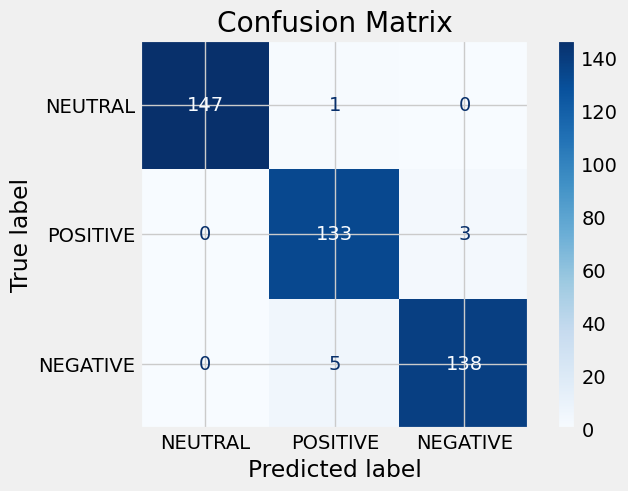

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NEUTRAL', 'POSITIVE', 'NEGATIVE'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from sklearn.metrics import cohen_kappa_score, f1_score, precision_score, recall_score

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Cohen's Kappa Score
kappa_score = cohen_kappa_score(y_true, y_pred_classes)

# F1 Score
f1 = f1_score(y_true, y_pred_classes, average='macro')

# Precision
precision = precision_score(y_true, y_pred_classes, average='macro')

# Recall
recall = recall_score(y_true, y_pred_classes, average='macro')


print(f"Cohen's Kappa Score: {kappa_score:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 269ms/step
Cohen's Kappa Score: 0.9684
F1 Score: 0.9786
Precision: 0.9785
Recall: 0.9787


In [ ]:
from sklearn.metrics import cohen_kappa_score, f1_score, precision_score, recall_score, accuracy_score
import pandas as pd

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true, y_pred_classes)
f1 = f1_score(y_true, y_pred_classes, average='macro')
precision = precision_score(y_true, y_pred_classes, average='macro')
recall = recall_score(y_true, y_pred_classes, average='macro')
kappa_score = cohen_kappa_score(y_true, y_pred_classes)

metrics = {
    "Accuracy": accuracy,
    "F1 Score": f1,
    "Precision": precision,
    "Recall": recall,
    "Cohen's Kappa": kappa_score
}

metrics_df = pd.DataFrame(metrics, index=["Score"]).T
print(metrics_df)


14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 329ms/step
                  Score
Accuracy       0.978923
F1 Score       0.978571
Precision      0.978519
Recall         0.978740
Cohen's Kappa  0.968372


ONLY CNN

<ipython-input-32-7578744b1721>:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_encoded = data.replace(label_mapping)


Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.6874 - loss: 1.0305 - val_accuracy: 0.8889 - val_loss: 0.4365
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.8673 - loss: 0.4954 - val_accuracy: 0.9240 - val_loss: 0.2164
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9131 - loss: 0.2611 - val_accuracy: 0.9415 - val_loss: 0.1802
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9215 - loss: 0.1945 - val_accuracy: 0.9006 - val_loss: 0.2109
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9328 - loss: 0.2103 - val_accuracy: 0.9591 - val_loss: 0.1413
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9448 - loss: 0.1306 - val_accuracy: 0.9123 - val_loss: 0.2203
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9534 - loss: 0.1684 - val_accuracy: 0.9415 - val_loss: 0.1492
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9477 - loss: 0.1276 - val_accuracy: 0.9474 - v

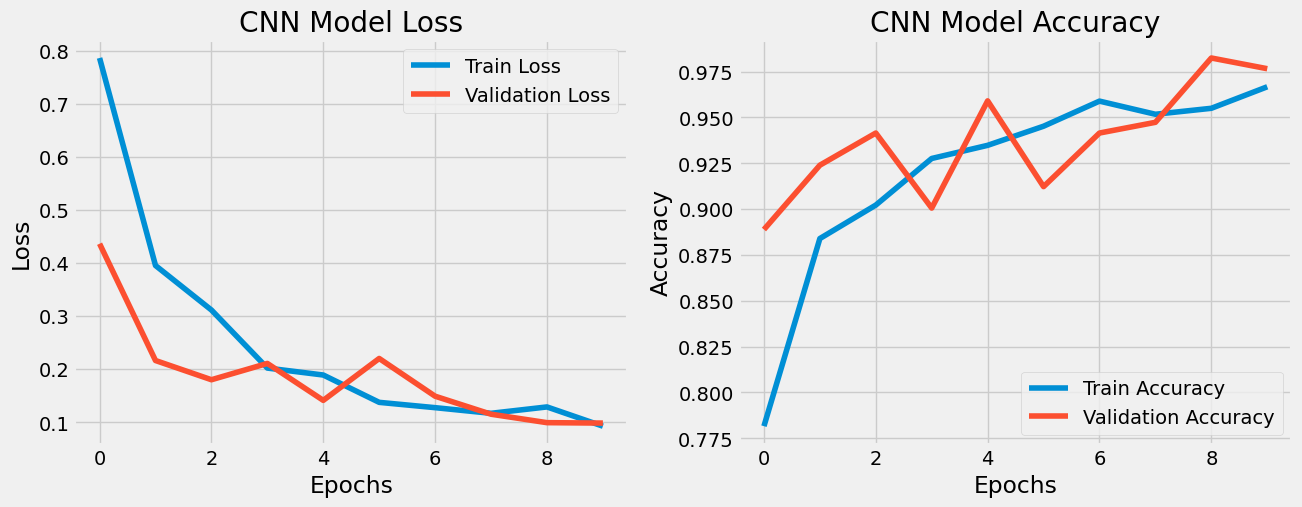

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input, BatchNormalization
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv("/content/emotions (2).csv")

# Step 1: Preprocess the EEG Signals
def preprocess_data(data):
    # Replace categorical labels with numbers
    label_mapping = {'NEUTRAL': 0, 'POSITIVE': 1, 'NEGATIVE': 2}
    data_encoded = data.replace(label_mapping)

    # Extract features and labels
    X = data_encoded.drop(columns=['label'])  # EEG signals
    y = data_encoded['label'].values  # Labels

    # Normalize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # One-hot encode labels
    y_onehot = to_categorical(y)

    # Reshape EEG signals for CNN
    num_channels = 32  # You can adjust this if necessary
    num_timesteps = X_scaled.shape[1] // num_channels

    # Ensure that the reshaping is valid
    if X_scaled.shape[1] % num_channels != 0:
        X_scaled = X_scaled[:, :(num_timesteps * num_channels)]

    X_reshaped = X_scaled.reshape(X_scaled.shape[0], num_timesteps, num_channels)
    x_train, x_test, y_train, y_test = train_test_split(X_reshaped, y_onehot, test_size=0.2, random_state=42)

    return x_train, x_test, y_train, y_test
x_train, x_test, y_train, y_test = preprocess_data(data)

# Step 2: Build the CNN Model
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # First Convolutional Block
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = MaxPooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # Second Convolutional Block
    x = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # Third Convolutional Block
    x = Conv1D(filters=256, kernel_size=3, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # Flatten and Dense Layers for classification
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(3, activation='softmax')(x)  # 3 classes: NEUTRAL, POSITIVE, NEGATIVE

    # Create the model
    model = tf.keras.Model(inputs=inputs, outputs=output)

    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model

# Build and compile the CNN model
cnn_model = build_cnn_model((x_train.shape[1], x_train.shape[2]))

# Train the CNN model
history = cnn_model.fit(x_train, y_train, epochs=10, validation_split=0.1, batch_size=32)

# Step 3: Evaluate the model on the test set
loss, accuracy = cnn_model.evaluate(x_test, y_test)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

# Step 4: Plotting Loss and Accuracy
plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


ONLY RNN

<ipython-input-33-9799c555243f>:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_encoded = data.replace(label_mapping)


Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.6622 - loss: 0.8638 - val_accuracy: 0.8596 - val_loss: 0.4217
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.8663 - loss: 0.4679 - val_accuracy: 0.9123 - val_loss: 0.2258
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.8684 - loss: 0.4375 - val_accuracy: 0.9415 - val_loss: 0.2028
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9182 - loss: 0.2722 - val_accuracy: 0.9357 - val_loss: 0.2181
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step - accuracy: 0.9300 - loss: 0.2317 - val_accuracy: 0.9181 - val_loss: 0.1996
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.9256 - loss: 0.2066 - val_accuracy: 0.9357 - val_loss: 0.1848
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - accuracy: 0.9290 - loss: 0.1898 - val_accuracy: 0.9415 - val_loss: 0.1453
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.9440 - loss: 0.1539 - val_accuracy: 0.9474 

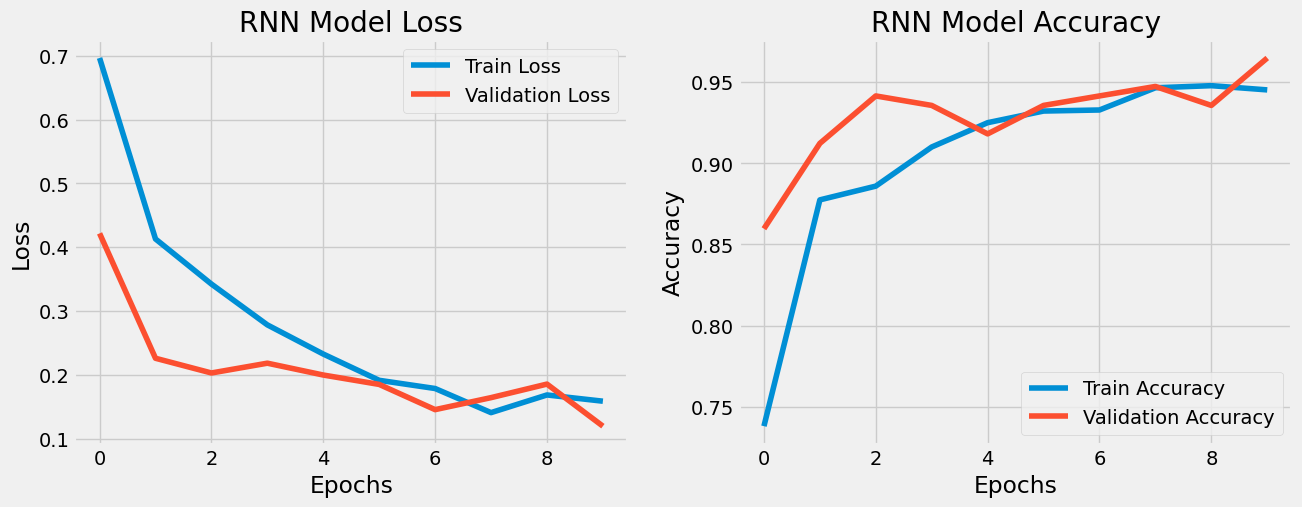

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Input
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv("/content/emotions (2).csv")

# Step 1: Preprocess the EEG Signals
def preprocess_data(data):
    # Replace categorical labels with numbers
    label_mapping = {'NEUTRAL': 0, 'POSITIVE': 1, 'NEGATIVE': 2}
    data_encoded = data.replace(label_mapping)

    # Extract features and labels
    X = data_encoded.drop(columns=['label'])
    y = data_encoded['label'].values  # Labels

    # Normalize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # One-hot encode labels
    y_onehot = to_categorical(y)

    # Reshape EEG signals for RNN
    num_channels = 32  # You can adjust this if necessary
    num_timesteps = X_scaled.shape[1] // num_channels

    # Ensure that the reshaping is valid
    if X_scaled.shape[1] % num_channels != 0:
        X_scaled = X_scaled[:, :(num_timesteps * num_channels)]

    X_reshaped = X_scaled.reshape(X_scaled.shape[0], num_timesteps, num_channels)

    # Split data into training and testing sets
    x_train, x_test, y_train, y_test = train_test_split(X_reshaped, y_onehot, test_size=0.2, random_state=42)

    return x_train, x_test, y_train, y_test

x_train, x_test, y_train, y_test = preprocess_data(data)

# Step 2: Build the RNN Model
def build_rnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # First RNN Layer
    x = SimpleRNN(128, return_sequences=True, activation='relu')(inputs)
    x = Dropout(0.3)(x)

    # Second RNN Layer
    x = SimpleRNN(128, return_sequences=False, activation='relu')(x)
    x = Dropout(0.3)(x)

    # Output Dense Layer for classification
    output = Dense(3, activation='softmax')(x)  # 3 classes: NEUTRAL, POSITIVE, NEGATIVE

    # Create the model
    model = tf.keras.Model(inputs=inputs, outputs=output)

    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model

# Build and compile the RNN model
rnn_model = build_rnn_model((x_train.shape[1], x_train.shape[2]))

# Train the RNN model
history = rnn_model.fit(x_train, y_train, epochs=10, validation_split=0.1, batch_size=32)

# Step 3: Evaluate the model on the test set
loss, accuracy = rnn_model.evaluate(x_test, y_test)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

# Step 4: Plotting Loss and Accuracy
plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('RNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('RNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


ONLY LSTM

<ipython-input-34-4dd3d546242d>:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_encoded = data.replace(label_mapping)


Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 250ms/step - accuracy: 0.7181 - loss: 0.6613 - val_accuracy: 0.8713 - val_loss: 0.2916
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 24s 320ms/step - accuracy: 0.8948 - loss: 0.2715 - val_accuracy: 0.9006 - val_loss: 0.1974
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 25s 406ms/step - accuracy: 0.9169 - loss: 0.2237 - val_accuracy: 0.9240 - val_loss: 0.1968
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 278ms/step - accuracy: 0.9401 - loss: 0.1610 - val_accuracy: 0.9591 - val_loss: 0.1382
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 260ms/step - accuracy: 0.9705 - loss: 0.1120 - val_accuracy: 0.9357 - val_loss: 0.1302
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 262ms/step - accuracy: 0.9605 - loss: 0.1276 - val_accuracy: 0.9357 - val_loss: 0.1442
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 263ms/step - accuracy: 0.9647 - loss: 0.1137 - val_accuracy: 0.9532 - val_loss: 0.1152
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 254ms/step - accuracy: 0.9810 - loss: 0.0571 - val_accu

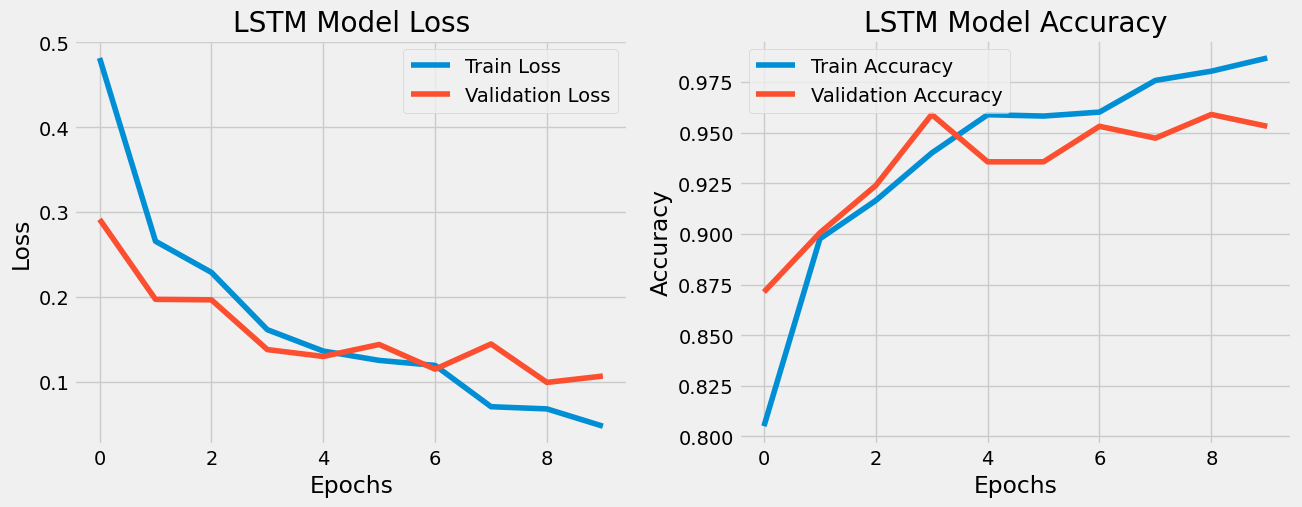

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv("/content/emotions (2).csv")

# Step 1: Preprocess the EEG Signals
def preprocess_data(data):
    # Replace categorical labels with numbers
    label_mapping = {'NEUTRAL': 0, 'POSITIVE': 1, 'NEGATIVE': 2}
    data_encoded = data.replace(label_mapping)

    # Extract features and labels
    X = data_encoded.drop(columns=['label'])  # EEG signals
    y = data_encoded['label'].values  # Labels

    # Normalize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # One-hot encode labels
    y_onehot = to_categorical(y)

    # Reshape EEG signals for LSTM
    num_channels = 32
    num_timesteps = X_scaled.shape[1] // num_channels

    # Ensure that reshaping is valid
    if X_scaled.shape[1] % num_channels != 0:
        X_scaled = X_scaled[:, :(num_timesteps * num_channels)]

    X_reshaped = X_scaled.reshape(X_scaled.shape[0], num_timesteps, num_channels)

    # Split data into training and testing sets
    x_train, x_test, y_train, y_test = train_test_split(X_reshaped, y_onehot, test_size=0.2, random_state=42)

    return x_train, x_test, y_train, y_test
x_train, x_test, y_train, y_test = preprocess_data(data)

# Step 2: Build the LSTM-only Model
def build_lstm_model(input_shape):
    inputs = Input(shape=input_shape)

    # First LSTM Layer
    x = LSTM(128, return_sequences=True)(inputs)
    x = Dropout(0.3)(x)

    # Second LSTM Layer
    x = LSTM(128, return_sequences=False)(x)
    x = Dropout(0.3)(x)

    # Output Dense Layer for classification
    output = Dense(3, activation='softmax')(x)  # 3 classes: NEUTRAL, POSITIVE, NEGATIVE

    # Create the model
    model = tf.keras.Model(inputs=inputs, outputs=output)

    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model

# Build and compile the LSTM model
lstm_model = build_lstm_model((x_train.shape[1], x_train.shape[2]))

# Train the LSTM model
history = lstm_model.fit(x_train, y_train, epochs=10, validation_split=0.1, batch_size=32)

# Step 3: Evaluate the model on the test set
loss, accuracy = lstm_model.evaluate(x_test, y_test)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

# Step 4: Plotting Loss and Accuracy
plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


RNN Test Accuracy: 0.9484777450561523
LSTM Test Accuracy: 0.9508196711540222
LSTM+Transformer Test Accuracy: 0.976580798625946


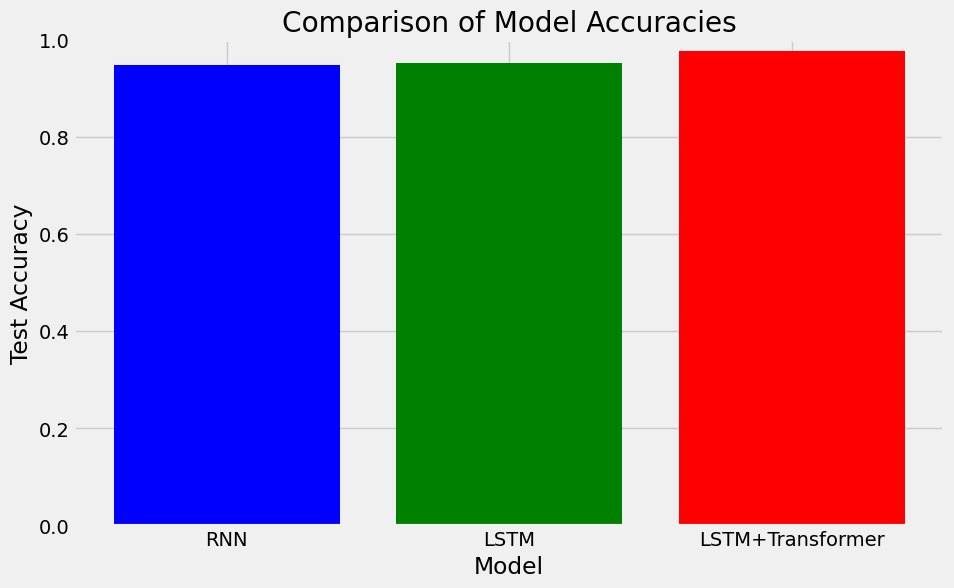

In [ ]:
import matplotlib.pyplot as plt

# Dictionary to store model accuracies
model_accuracies = {}

# Train and evaluate RNN model
rnn_model = build_rnn_model(input_shape=(x_train.shape[1], x_train.shape[2]))  # Assume RNN model function is defined
rnn_model.fit(x_train, y_train, epochs=10, validation_split=0.1, batch_size=32, verbose=0)
_, rnn_accuracy = rnn_model.evaluate(x_test, y_test, verbose=0)
model_accuracies['RNN'] = rnn_accuracy
print(f"RNN Test Accuracy: {rnn_accuracy}")

# Train and evaluate LSTM model
lstm_model = build_lstm_model(input_shape=(x_train.shape[1], x_train.shape[2]))  # Assume LSTM model function is defined
lstm_model.fit(x_train, y_train, epochs=10, validation_split=0.1, batch_size=32, verbose=0)
_, lstm_accuracy = lstm_model.evaluate(x_test, y_test, verbose=0)
model_accuracies['LSTM'] = lstm_accuracy
print(f"LSTM Test Accuracy: {lstm_accuracy}")


# Train and evaluate LSTM+Transformer model
lstm_transformer_model = build_lstm_transformer_model(input_shape=(x_train.shape[1], x_train.shape[2]))  # LSTM+Transformer
lstm_transformer_model.fit(x_train, y_train, epochs=10, validation_split=0.1, batch_size=32, verbose=0)
_, lstm_transformer_accuracy = lstm_transformer_model.evaluate(x_test, y_test, verbose=0)
model_accuracies['LSTM+Transformer'] = lstm_transformer_accuracy
print(f"LSTM+Transformer Test Accuracy: {lstm_transformer_accuracy}")

# Plotting the accuracies for comparison
models = list(model_accuracies.keys())
accuracies = list(model_accuracies.values())

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['blue', 'green', 'red', 'purple'])
plt.title('Comparison of Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)  # Accuracy range between 0 and 1
plt.show()
